### EDA and discovery


In [2]:
import pandas as pd
import os

data_dir = 'planets-dataset/planet/planet'
df = pd.read_csv(os.path.join(data_dir, 'train_classes.csv'))
df['filename'] = df['image_name'] + '.jpg'

tags_split = df['tags'].str.get_dummies(sep=' ')
df = pd.concat([df, tags_split], axis=1)

print(df.shape)
print(df.columns.duplicated().sum())  # must print 0 before continuing

(40479, 20)
0


In [3]:
import os

print(os.listdir('planets-dataset/planet/planet'))

['sample_submission.csv', 'test-jpg', 'train-jpg', 'train_classes.csv']


In [4]:
#image folder
image_dir = os.path.join(data_dir, 'train-jpg')
print(os.listdir(image_dir)[:5])

['train_0.jpg', 'train_1.jpg', 'train_10.jpg', 'train_100.jpg', 'train_1000.jpg']


In [5]:
tag_counts = tags_split.sum().sort_values(ascending=False)
print(tag_counts)

primary              37513
clear                28431
agriculture          12315
road                  8071
water                 7411
partly_cloudy         7261
cultivation           4477
habitation            3660
haze                  2697
cloudy                2089
bare_ground            862
selective_logging      340
artisinal_mine         339
blooming               332
slash_burn             209
conventional_mine      100
blow_down               98
dtype: int64


In [6]:
cooccurrence = tags_split.T.dot(tags_split)
print(cooccurrence)


                   agriculture  artisinal_mine  bare_ground  blooming  \
agriculture              12315              38          225        32   
artisinal_mine              38             339           40         0   
bare_ground                225              40          862         3   
blooming                    32               0            3       332   
blow_down                   22               0            4         1   
clear                     9150             307          747       311   
cloudy                       0               0            0         0   
conventional_mine           24               4           10         0   
cultivation               3377              18           89        35   
habitation                2737              29          163         4   
haze                       672               5           41         4   
partly_cloudy             2493              27           74        17   
primary                  11972             324     

In [7]:
print(df.columns.tolist())
print(df.columns[df.columns.duplicated()])

['image_name', 'tags', 'filename', 'agriculture', 'artisinal_mine', 'bare_ground', 'blooming', 'blow_down', 'clear', 'cloudy', 'conventional_mine', 'cultivation', 'habitation', 'haze', 'partly_cloudy', 'primary', 'road', 'selective_logging', 'slash_burn', 'water']
Index([], dtype='str')


In [8]:
#tagging priority: resource_extraction > agricultural_clearing > infrastructure_other > undisturbed

import numpy as np

extraction_tags = ['selective_logging', 'artisinal_mine', 'conventional_mine']
agriculture_tags = ['agriculture', 'cultivation', 'slash_burn']
infrastructure_tags = ['road', 'habitation', 'blow_down']

conditions = [
    df[extraction_tags].sum(axis=1) > 0,
    df[agriculture_tags].sum(axis=1) > 0,
    df[infrastructure_tags].sum(axis=1) > 0,
    df['primary'] == 1,
]
choices = ['resource_extraction', 'agricultural_clearing', 'infrastructure_other', 'undisturbed']

df['label'] = np.select(conditions, choices, default='unlabeled')
print(df['label'].value_counts())

label
undisturbed              22038
agricultural_clearing    13300
unlabeled                 2472
infrastructure_other      1900
resource_extraction        769
Name: count, dtype: int64


In [9]:
#remove unlabled rows
df_clean = df[df['label'] != 'unlabeled'].copy()
print(len(df_clean))

38007


In [10]:
from sklearn.utils.class_weight import compute_class_weight
import torch
import numpy as np

classes = np.array(df_clean['label'].unique())
weights = compute_class_weight('balanced', classes=classes, y=df_clean['label'])
class_weight_dict = dict(zip(classes, weights))
print(class_weight_dict)

# convert to tensor in the order your model's output layer expects
class_names = ['undisturbed', 'agricultural_clearing', 'infrastructure_other', 'resource_extraction']
weight_tensor = torch.tensor([class_weight_dict[c] for c in class_names], dtype=torch.float32)

{'undisturbed': np.float64(0.43115300843996734), 'agricultural_clearing': np.float64(0.7144172932330827), 'infrastructure_other': np.float64(5.000921052631579), 'resource_extraction': np.float64(12.355981794538362)}


In [11]:
class_names = ['undisturbed', 'agricultural_clearing', 'infrastructure_other', 'resource_extraction']
weight_tensor = torch.tensor([class_weight_dict[c] for c in class_names], dtype=torch.float32)
print(weight_tensor)

tensor([ 0.4312,  0.7144,  5.0009, 12.3560])


In [12]:
label_to_idx = {name: i for i, name in enumerate(class_names)}
df_clean['label_idx'] = df_clean['label'].map(label_to_idx)

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df_clean, 
    test_size=0.2, 
    stratify=df_clean['label'], 
    random_state=42
)
print(train_df['label'].value_counts(normalize=True))
print(test_df['label'].value_counts(normalize=True))

label
undisturbed              0.579839
agricultural_clearing    0.349942
infrastructure_other     0.049992
resource_extraction      0.020227
Name: proportion, dtype: float64
label
undisturbed              0.579847
agricultural_clearing    0.349908
infrastructure_other     0.049987
resource_extraction      0.020258
Name: proportion, dtype: float64


In [13]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [14]:
from torch.utils.data import Dataset
from PIL import Image
import os

class ForestDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_path = os.path.join(self.image_dir, row['filename'])
        image = Image.open(img_path).convert('RGB')
        label = row['label_idx']
        if self.transform:
            image = self.transform(image)
        return image, label

In [15]:
from torch.utils.data import DataLoader

train_dataset = ForestDataset(train_df, image_dir, transform=train_transform)
test_dataset = ForestDataset(test_df, image_dir, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# quick sanity check
images, labels = next(iter(train_loader))
print(images.shape, labels.shape)

torch.Size([32, 3, 128, 128]) torch.Size([32])


In [16]:
import torch.nn as nn
import torch.nn.functional as F

class ForestCNN(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(128 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 128 -> 64
        x = self.pool(F.relu(self.conv2(x)))  # 64 -> 32
        x = self.pool(F.relu(self.conv3(x)))  # 32 -> 16
        x = self.pool(F.relu(self.conv4(x)))  # 16 -> 8
        x = x.view(x.size(0), -1)  # flatten
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)  # raw logits, no softmax here
        return x

In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)  # should print 'cuda' on your 1070

model = ForestCNN(num_classes=4).to(device)
criterion = nn.CrossEntropyLoss(weight=weight_tensor.to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

cuda


In [18]:
import torch
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

2.5.1+cu121
12.1
True


In [19]:
import time

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

In [20]:
import numpy as np
from PIL import Image

def preload_images(df, image_dir, size=128):
    images = np.zeros((len(df), size, size, 3), dtype=np.uint8)
    for i, row in enumerate(df.itertuples()):
        img = Image.open(os.path.join(image_dir, row.filename)).convert('RGB').resize((size, size))
        images[i] = np.array(img)
        if i % 5000 == 0:
            print(f"{i}/{len(df)}")
    return images

train_images = preload_images(train_df, image_dir)
test_images = preload_images(test_df, image_dir)

0/30405
5000/30405
10000/30405
15000/30405
20000/30405
25000/30405
30000/30405
0/7602
5000/7602


In [21]:
start = time.time()
train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
elapsed = time.time() - start

print(f"Epoch time: {elapsed:.1f}s")
print(f"Train loss: {train_loss:.4f}, Train acc: {train_acc:.4f}")

Epoch time: 151.2s
Train loss: 1.2205, Train acc: 0.6761


In [22]:
num_epochs = 20
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0

for epoch in range(num_epochs):
    start = time.time()
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, test_loader, criterion, device)
    elapsed = time.time() - start

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} ({elapsed:.0f}s) — "
          f"train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f}, "
          f"val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  → saved new best model (val_acc: {val_acc:.4f})")

Epoch 1/20 (172s) — train_loss: 1.0542, train_acc: 0.7183, val_loss: 0.9483, val_acc: 0.7506
  → saved new best model (val_acc: 0.7506)
Epoch 2/20 (170s) — train_loss: 0.9638, train_acc: 0.7372, val_loss: 0.9218, val_acc: 0.7202
Epoch 3/20 (171s) — train_loss: 0.9344, train_acc: 0.7516, val_loss: 0.9056, val_acc: 0.7833
  → saved new best model (val_acc: 0.7833)
Epoch 4/20 (170s) — train_loss: 0.9063, train_acc: 0.7647, val_loss: 0.9081, val_acc: 0.8057
  → saved new best model (val_acc: 0.8057)
Epoch 5/20 (170s) — train_loss: 0.8712, train_acc: 0.7746, val_loss: 0.8339, val_acc: 0.7674
Epoch 6/20 (171s) — train_loss: 0.8600, train_acc: 0.7727, val_loss: 0.8481, val_acc: 0.8060
  → saved new best model (val_acc: 0.8060)
Epoch 7/20 (171s) — train_loss: 0.8510, train_acc: 0.7843, val_loss: 0.8048, val_acc: 0.8066
  → saved new best model (val_acc: 0.8066)
Epoch 8/20 (171s) — train_loss: 0.8245, train_acc: 0.7923, val_loss: 0.8212, val_acc: 0.7941
Epoch 9/20 (171s) — train_loss: 0.8160, t

In [23]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

C:\Users\Warner Nash\AppData\Local\Temp\ipykernel_4204\3560448680.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pth'))


                       precision    recall  f1-score   support

          undisturbed       0.95      0.84      0.89      4408
agricultural_clearing       0.79      0.86      0.83      2660
 infrastructure_other       0.32      0.45      0.38       380
  resource_extraction       0.34      0.60      0.44       154

             accuracy                           0.82      7602
            macro avg       0.60      0.69      0.63      7602
         weighted avg       0.85      0.82      0.83      7602



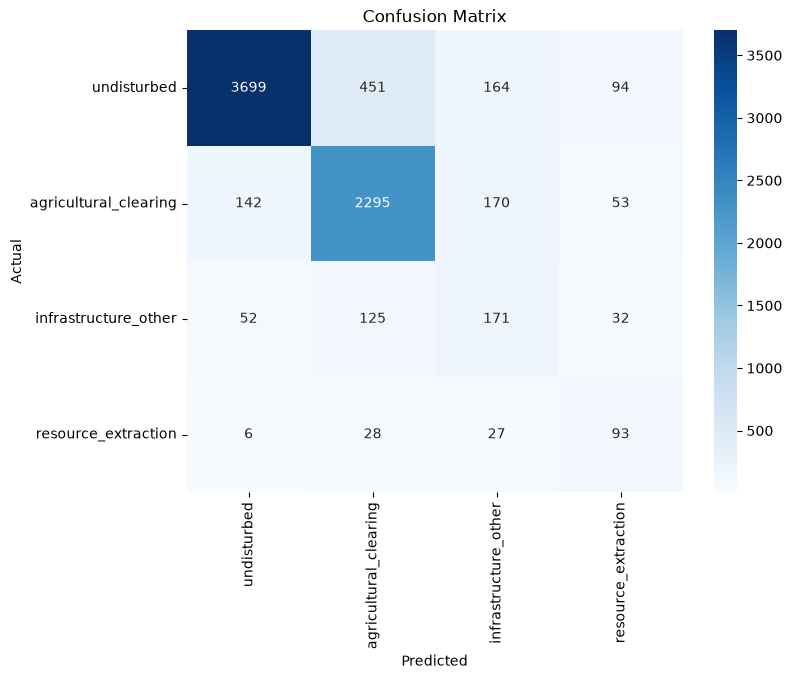

In [26]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)
print(classification_report(all_labels, all_preds, target_names=class_names))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

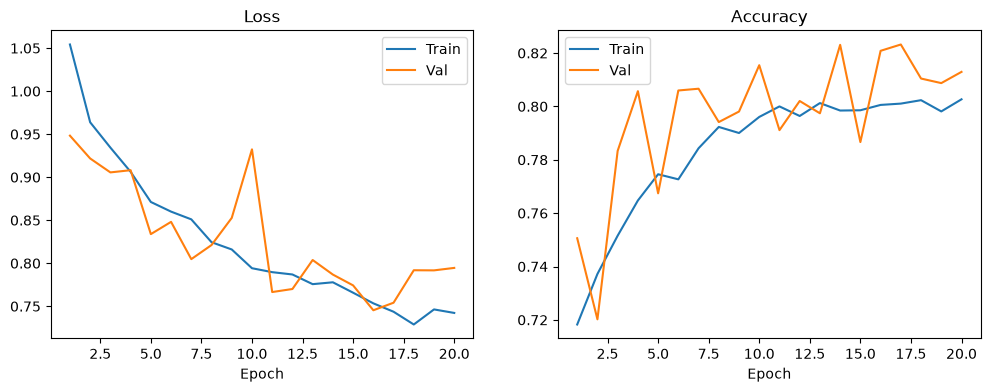

In [31]:
epochs_range = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs_range, history['train_loss'], label='Train')
axes[0].plot(epochs_range, history['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(epochs_range, history['train_acc'], label='Train')
axes[1].plot(epochs_range, history['val_acc'], label='Val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

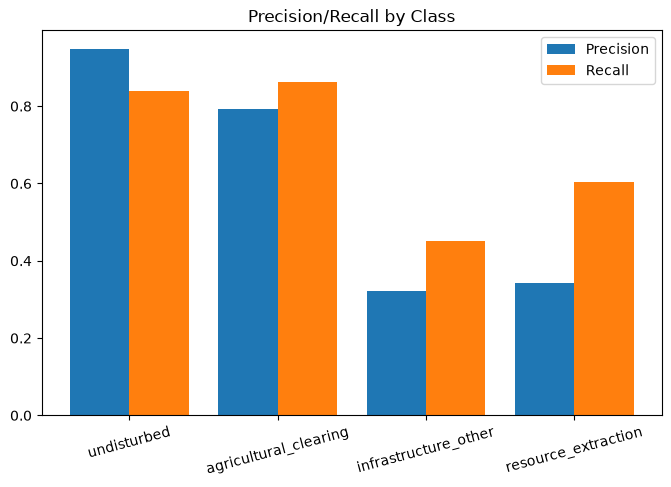

In [32]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(all_labels, all_preds)
x = np.arange(len(class_names))

plt.figure(figsize=(8, 5))
plt.bar(x - 0.2, precision, 0.4, label='Precision')
plt.bar(x + 0.2, recall, 0.4, label='Recall')
plt.xticks(x, class_names, rotation=15)
plt.legend()
plt.title('Precision/Recall by Class')
plt.savefig('precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()

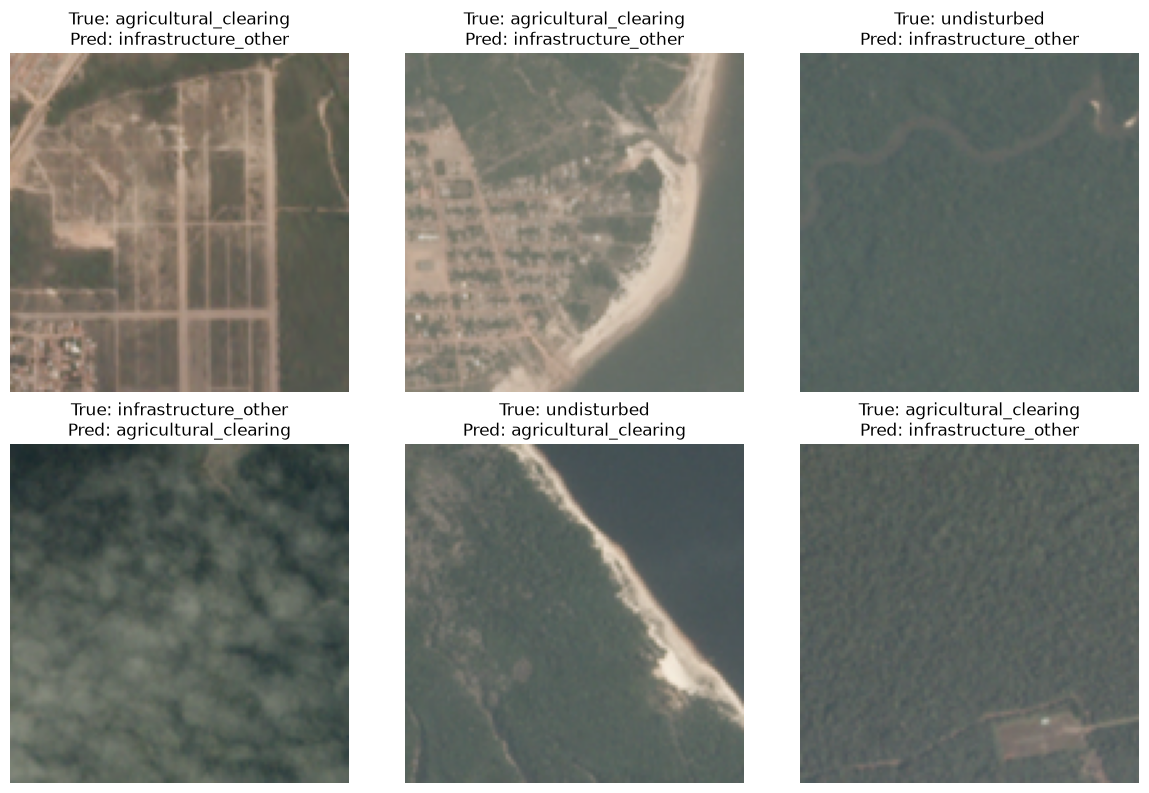

In [33]:
import random

misclassified_idx = [i for i in range(len(all_labels)) if all_labels[i] != all_preds[i]]
sample_idx = random.sample(misclassified_idx, 6)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, idx in zip(axes.flat, sample_idx):
    ax.imshow(test_images[idx])
    ax.set_title(f"True: {class_names[all_labels[idx]]}\nPred: {class_names[all_preds[idx]]}")
    ax.axis('off')
plt.tight_layout()
plt.savefig('misclassified_examples.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, class_idx].backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)  # global avg pool per channel
        cam = (weights * self.activations).sum(dim=1).squeeze()
        cam = F.relu(cam)  # only positive influence
        cam = cam / (cam.max() + 1e-8)  # normalize 0-1
        return cam.cpu().numpy(), class_idx

In [28]:
grad_cam = GradCAM(model, model.conv4)

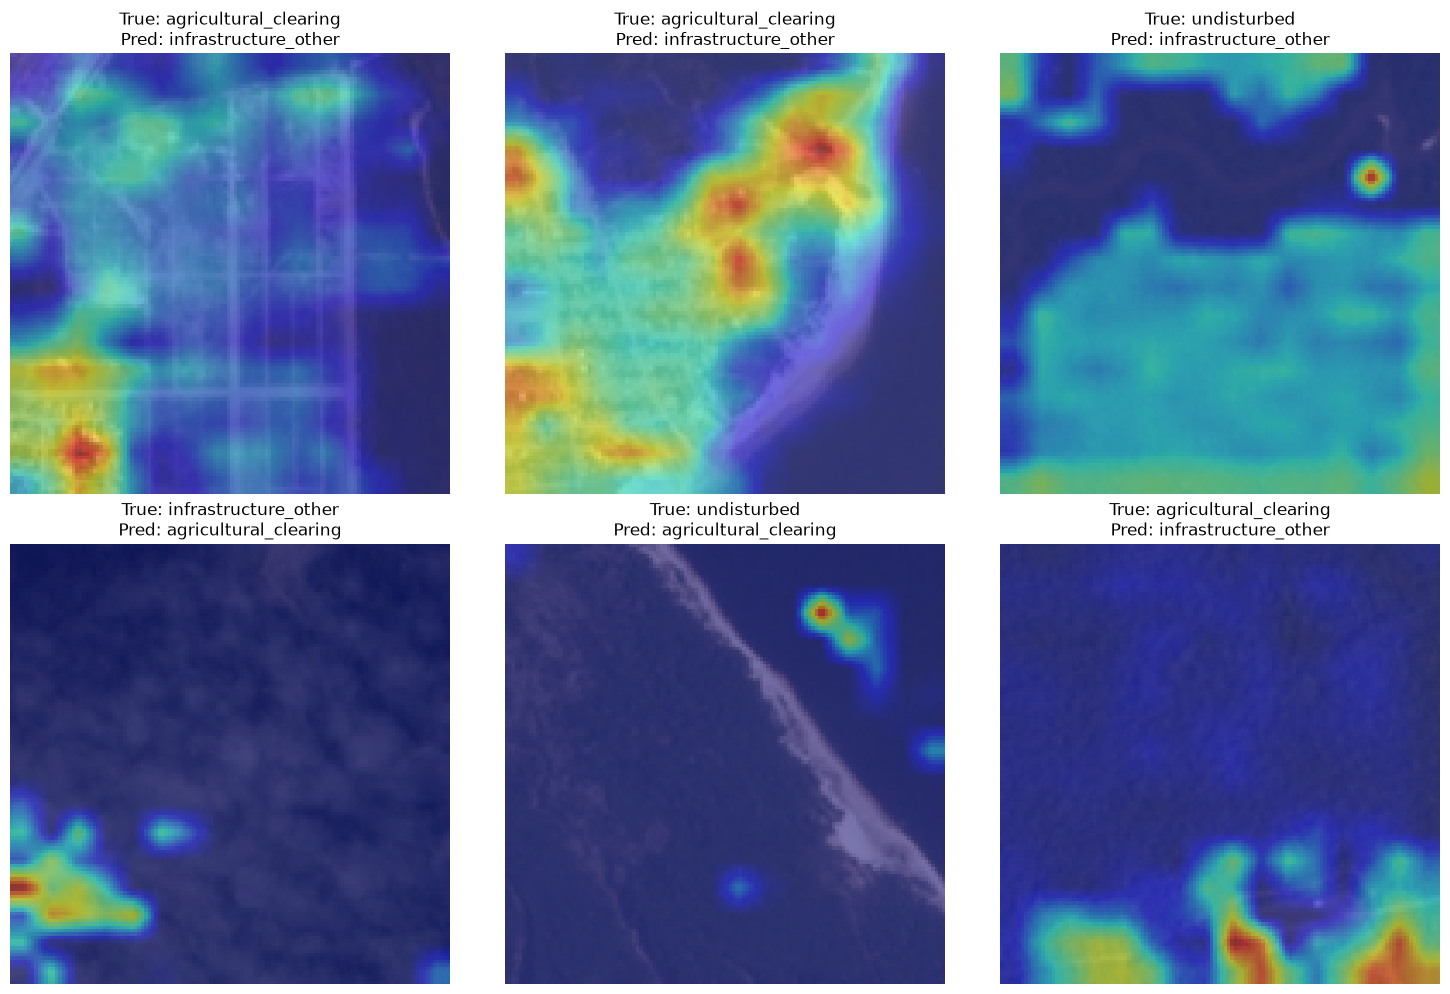

In [34]:
import cv2

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, idx in zip(axes.flat, sample_idx):
    img_tensor = test_dataset[idx][0].unsqueeze(0).to(device)
    true_label = all_labels[idx]

    cam, pred_class = grad_cam.generate(img_tensor)
    cam_resized = cv2.resize(cam, (128, 128))

    original_img = test_images[idx]
    heatmap = plt.cm.jet(cam_resized)[:, :, :3]
    overlay = 0.5 * original_img / 255.0 + 0.5 * heatmap

    ax.imshow(overlay)
    ax.set_title(f"True: {class_names[true_label]}\nPred: {class_names[pred_class]}")
    ax.axis('off')

plt.tight_layout()
plt.savefig('gradcam_examples.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
features_batch = None
def hook_fn(module, input, output):
    global features_batch
    features_batch = output.detach()

hook = model.fc1.register_forward_hook(hook_fn)

all_probs, all_features, all_preds, all_labels = [], [], [], []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)

        all_probs.append(probs.cpu().numpy())
        all_features.append(features_batch.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

hook.remove()
all_probs = np.concatenate(all_probs)
all_features = np.concatenate(all_features)
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
correct = (all_preds == all_labels)

In [37]:
test_df_reset = test_df.reset_index(drop=True)

for cloud_tag in ['clear', 'haze', 'cloudy', 'partly_cloudy']:
    mask = test_df_reset[cloud_tag] == 1
    if mask.sum() > 0:
        acc = correct[mask.values].mean()
        print(f"{cloud_tag}: n={mask.sum()}, accuracy={acc:.3f}")

clear: n=5646, accuracy=0.833
haze: n=528, accuracy=0.799
partly_cloudy: n=1428, accuracy=0.793


Correct — mean confidence: 0.811
Incorrect — mean confidence: 0.571


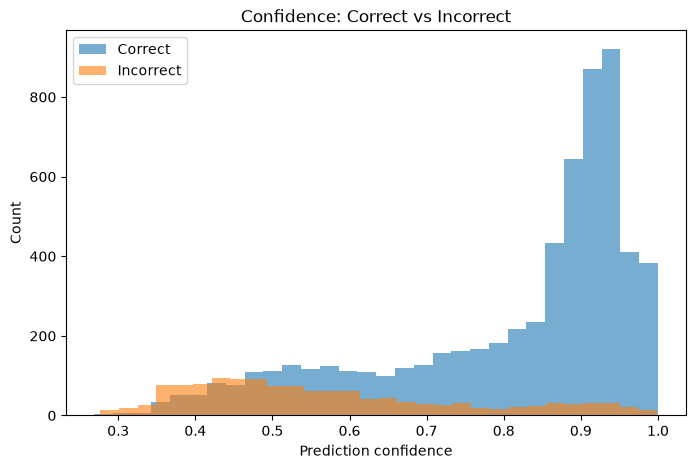

In [38]:
confidences = all_probs.max(axis=1)
print(f"Correct — mean confidence: {confidences[correct].mean():.3f}")
print(f"Incorrect — mean confidence: {confidences[~correct].mean():.3f}")

plt.figure(figsize=(8, 5))
plt.hist(confidences[correct], bins=30, alpha=0.6, label='Correct')
plt.hist(confidences[~correct], bins=30, alpha=0.6, label='Incorrect')
plt.xlabel('Prediction confidence'); plt.ylabel('Count'); plt.legend()
plt.title('Confidence: Correct vs Incorrect')
plt.savefig('confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

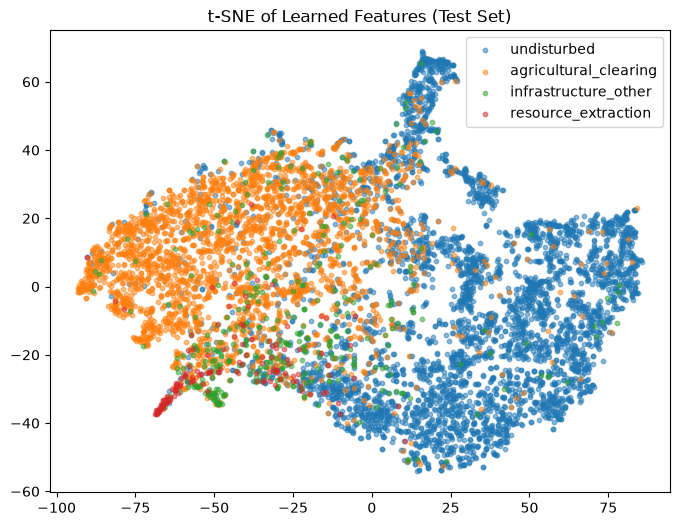

In [39]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
features_2d = tsne.fit_transform(all_features)

plt.figure(figsize=(8, 6))
for i, name in enumerate(class_names):
    mask = all_labels == i
    plt.scatter(features_2d[mask, 0], features_2d[mask, 1], label=name, alpha=0.5, s=10)
plt.legend()
plt.title('t-SNE of Learned Features (Test Set)')
plt.savefig('tsne_features.png', dpi=150, bbox_inches='tight')
plt.show()